**Parameter Estimation**
========================

In [2]:
import pandas as pd
import lmoments3 as lm
from lmoments3 import distr

# Step 1: Read CSV file and extract 'Max Value (mm)' column
file_path = 'C:\\Users\\khfy3\\OneDrive\\Desktop\\Master Final Sem\\Coding\\Data\\Annual\\0600011RF.csv'
data = pd.read_csv(file_path)['Value (mm)']

# Step 2: Install and Import lmoments3 (assuming lmoments3 is already installed)

# Step 3: Estimate L-moments from the data
l_moments = lm.lmom_ratios(data, nmom=4)

# Step 4 & 5: Fit distributions and estimate parameters
distributions = ['gum', 'nor', 'exp', 'gev', 'glo', 'gno', 'gpa', 'pe3','kap']
estimated_parameters = {}

for dist_name in distributions:
    dist = getattr(distr, dist_name)
    params = dist.lmom_fit(data)
    estimated_parameters[dist_name] = dict(params)

# Print estimated parameters for each distribution
for dist_name, params in estimated_parameters.items():
    print(f"{dist_name.upper()} Distribution Parameters: {params}")


GUM Distribution Parameters: {'loc': 166.33411528830575, 'scale': 65.99837598464822}
NOR Distribution Parameters: {'loc': 204.42941176470583, 'scale': 81.08371648343602}
EXP Distribution Parameters: {'loc': 112.93623529411761, 'scale': 91.49317647058822}
GEV Distribution Parameters: {'c': -0.033013624717955325, 'loc': 165.35893845033127, 'scale': 63.956267647058276}
GLO Distribution Parameters: {'k': -0.19131743777270008, 'loc': 190.29056614340573, 'scale': 43.04158051796322}
GNO Distribution Parameters: {'k': -0.3949627848267513, 'loc': 188.82493225872443, 'scale': 75.97592869037408}
GPA Distribution Parameters: {'c': -0.3576273402649449, 'loc': 96.57600461733374, 'scale': 146.424734283999}
PE3 Distribution Parameters: {'skew': 1.1585208940282958, 'loc': 204.42941176470583, 'scale': 84.54081031289051}
KAP Distribution Parameters: {'k': 0.011838019085818276, 'h': 0.1582404633694279, 'loc': 158.9836582233583, 'scale': 70.67987763626365}


**Plotting**
============

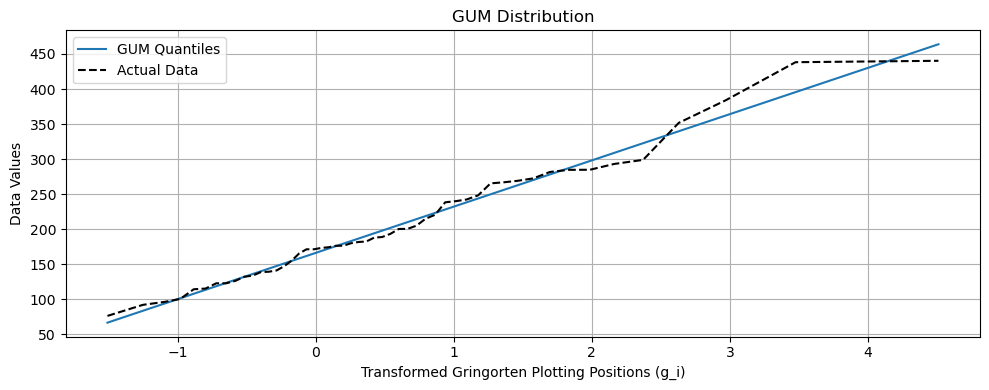

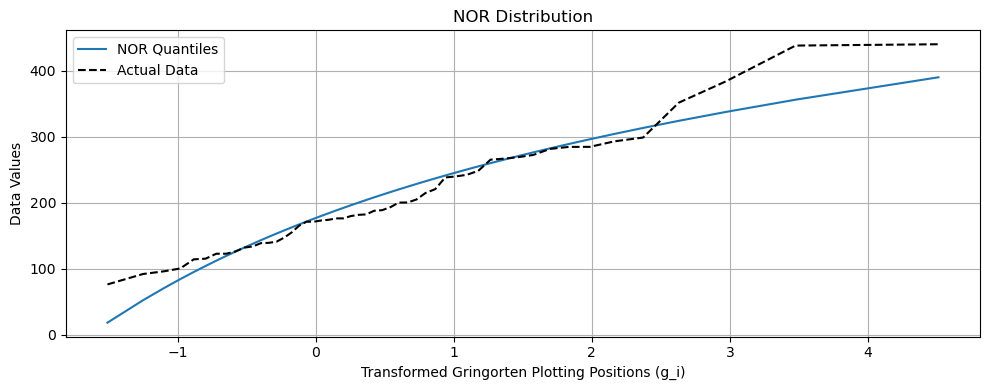

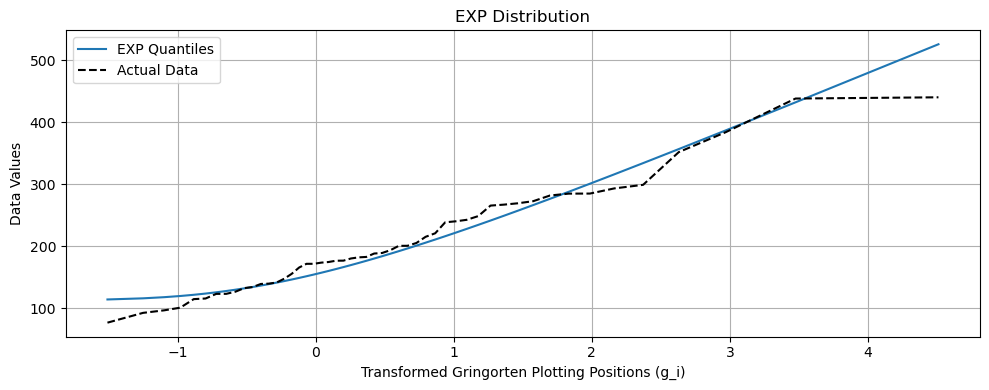

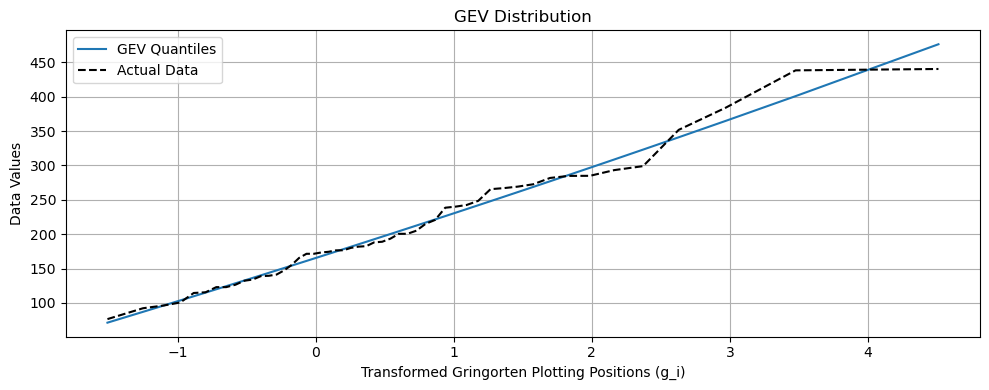

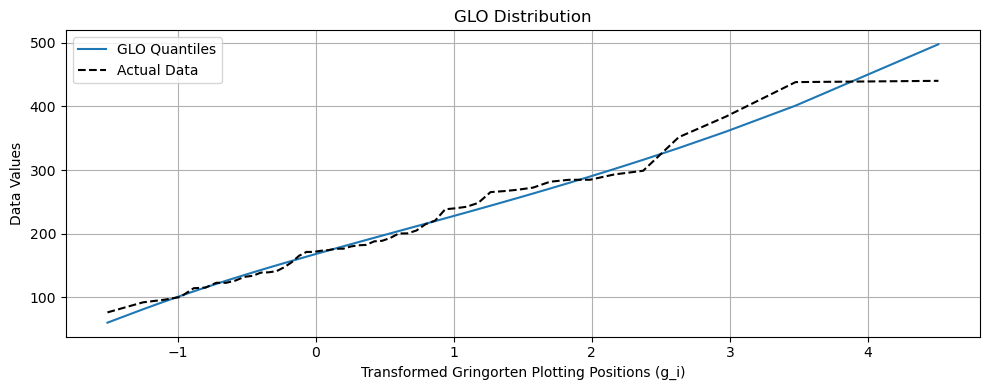

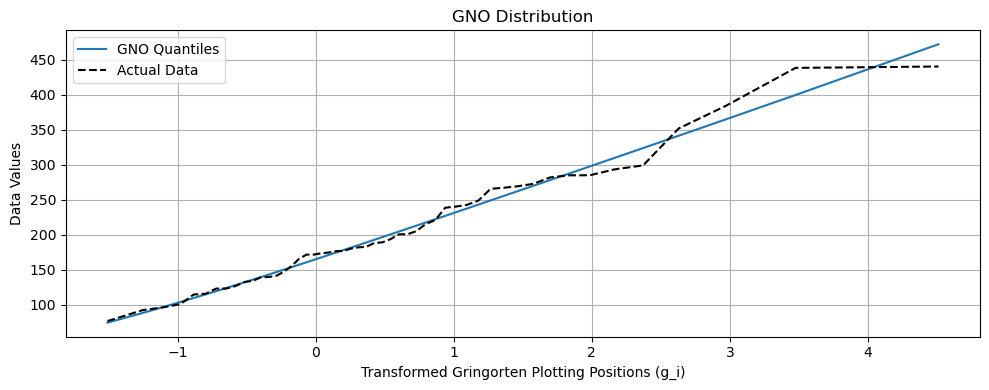

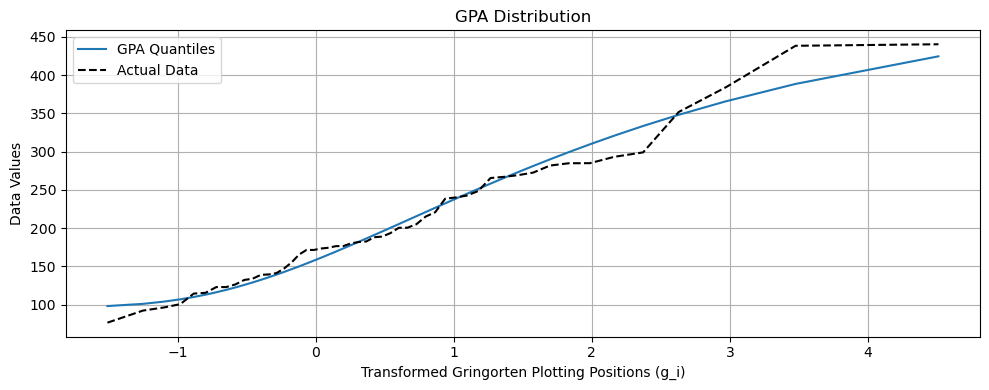

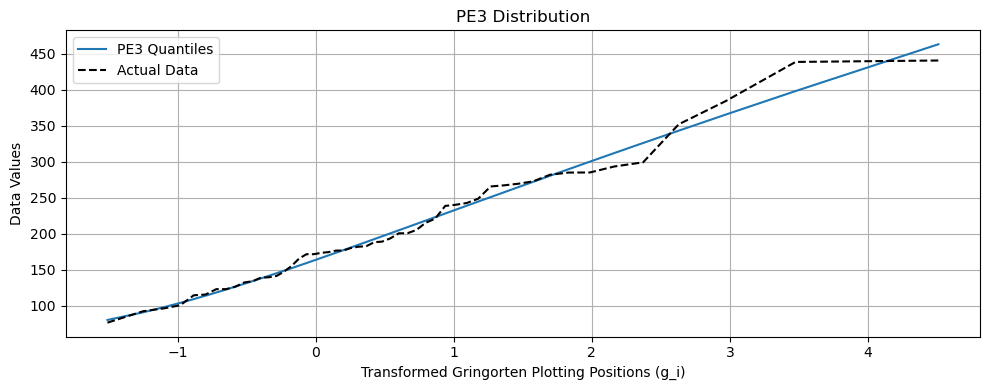

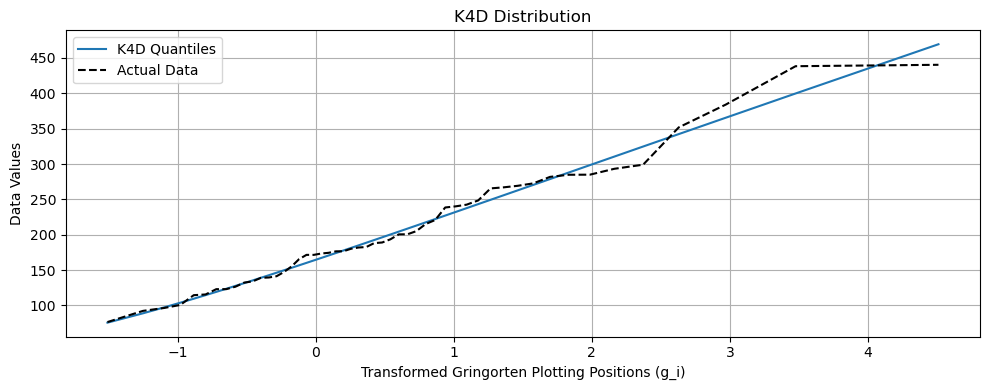

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import lmoments3 as lm
from lmoments3 import distr

# Function to calculate Gringorten plotting positions
def gringorten_plotting_positions(n):
    return [(i - 0.44) / (n + 0.12) for i in range(1, n + 1)]

# Function to calculate g_i
def calculate_gi(P_i):
    return [-np.log(-np.log(P)) for P in P_i]

# Load your data (replace with your actual data loading code)
#file_path = 'C:\\Users\\khfy3\\OneDrive\\Desktop\\MSc Data Kemaman\\Annual Maximum Kemaman.csv'
data = pd.read_csv(file_path)['Value (mm)']

# Calculate Gringorten plotting positions and g_i
n = len(data)
P_i = gringorten_plotting_positions(n)
g_i = calculate_gi(P_i)

# Fit distributions and get parameters
distributions = ['gum', 'nor','exp','gev', 'glo', 'gno', 'gpa', 'pe3',  'kap']
fitted_params = {dist: getattr(distr, dist).lmom_fit(data) for dist in distributions}

# Calculate quantiles for each distribution
quantiles = {dist: getattr(distr, dist).ppf(P_i, **params) for dist, params in fitted_params.items()}

# Sorted data for actual data plot
sorted_data = sorted(data)

# Mapping for distribution names (for titles and legends)
dist_names = {'gum': 'GUM', 'nor': 'NOR','exp':'EXP','gev': 'GEV', 'glo': 'GLO', 'gno': 'GNO', 'gpa': 'GPA', 'pe3': 'PE3',  'kap': 'K4D'}

for dist in distributions:
    # Create a new figure for each distribution
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Plot the quantiles and actual data
    ax.plot(g_i, quantiles[dist], label=f'{dist_names[dist]} Quantiles')
    ax.plot(g_i, sorted_data, label='Actual Data', linestyle='--', color='black')
    
    # Set titles and labels
    ax.set_title(f'{dist_names[dist]} Distribution')
    ax.set_xlabel('Transformed Gringorten Plotting Positions (g_i)')
    ax.set_ylabel('Data Values')
    
    # Add legend and grid
    ax.legend()
    ax.grid(True)
    
    # Tight layout for the current figure
    plt.tight_layout()
    
    # Save the current figure
    plt.savefig(f'plotmadi_{dist}.png')
    
    # Show the plot if needed, otherwise you can comment this out
    plt.show()
    
    # Close the current figure to free memory
    plt.close(fig)



**Calculate MADI/MSDI**
=======================

In [6]:
import numpy as np

# Assuming 'sorted_data' contains the observed data (x_i)
# and 'quantiles' contains the predicted data (z_i) for each distribution

madi = {}
msdi = {}

for dist in distributions:
    # Normalized differences between empirical and theoretical quantiles
    normalized_differences = (sorted_data - quantiles[dist]) / sorted_data
    
    # MADI
    madi[dist] = np.mean(np.abs(normalized_differences))
    
    # MSDI
    msdi[dist] = np.mean((normalized_differences)**2)

# Print the MADI and MSDI for each distribution
for dist in distributions:
    print(f"{dist.upper()} Distribution:")
    print(f"  MADI: {madi[dist]:.4f}")  # Adjusted for formatting to 4 decimal places
    print(f"  MSDI: {msdi[dist]:.4f}\n")  # Adjusted for formatting to 4 decimal places


GUM Distribution:
  MADI: 0.0340
  MSDI: 0.0018

NOR Distribution:
  MADI: 0.0894
  MSDI: 0.0223

EXP Distribution:
  MADI: 0.0696
  MSDI: 0.0113

GEV Distribution:
  MADI: 0.0315
  MSDI: 0.0015

GLO Distribution:
  MADI: 0.0410
  MSDI: 0.0029

GNO Distribution:
  MADI: 0.0301
  MSDI: 0.0013

GPA Distribution:
  MADI: 0.0476
  MSDI: 0.0042

PE3 Distribution:
  MADI: 0.0298
  MSDI: 0.0014

KAP Distribution:
  MADI: 0.0294
  MSDI: 0.0013



**Combine Plot in One Graph**
=======

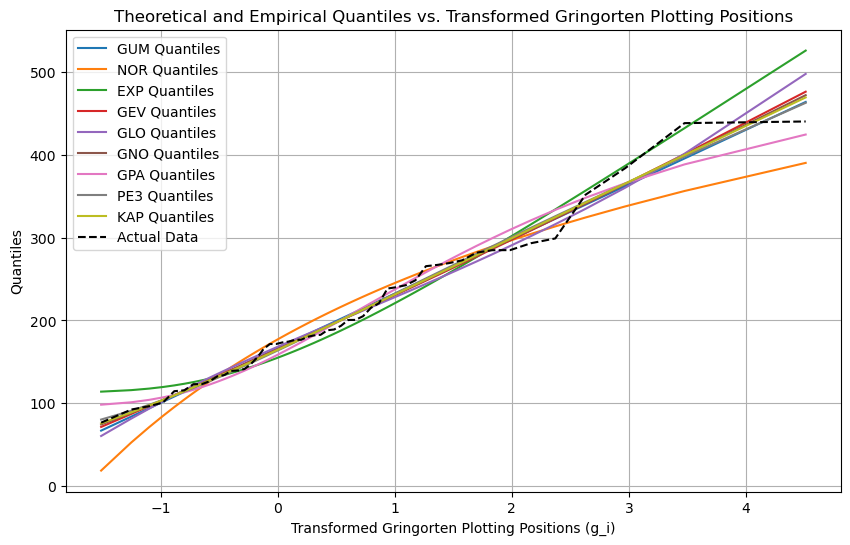

In [8]:
# Plotting
plt.figure(figsize=(10, 6))

# Plot theoretical quantiles for each distribution
for dist, q in quantiles.items():
    plt.plot(g_i, q, label=f'{dist.upper()} Quantiles')

# Plot actual data
sorted_data = sorted(data)
plt.plot(g_i, sorted_data, label='Actual Data', linestyle='--', color='black')

plt.xlabel('Transformed Gringorten Plotting Positions (g_i)')
plt.ylabel('Quantiles')
plt.title('Theoretical and Empirical Quantiles vs. Transformed Gringorten Plotting Positions')
plt.legend()
plt.grid(True)
plt.show()
